In [1]:
from utils import load_player, dev_sigmoid_c, dev_f_w_v, exe_player, plot_exp,means_exp,plot_evolution, plot_interval_widths_by_player
import pandas as pd
import numpy as np

df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')

c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


##### Optimisation $l_r$ and $q_0$

In [ ]:
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])

method="ECI"
name_methods = ["ECI_sig","ECI_my"]
l_rs=[8,4,2,1,0.5,0.1,0.05,0.01,0.005,0.001]
q_1=range(0,21)
test_v=range(1,21)

player='MHSC-65'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
best_results = {}

for method_f in name_methods: 
    best_mean_width = float("inf")
    best_result = None
    best_params = None
    best_stats = None
    for l_r in l_rs:
        for q in q_1:
            for v in test_v:
                #print(f'l_r={l_r}; q_0={q}')
                functions={"ECI_sig":dev_sigmoid_c(1),"ECI_my":dev_f_w_v(w,np.array([v]),alpha)}
                result = exe_player(
                    df_player,
                    player,
                    start_train,
                    end_train,
                    start_test,
                    end_test,
                    basemodel,
                    method,
                    alpha,
                    cv_search,
                    cv_method,
                    n_iter_search,
                    with_acute_load,
                    retrain_every_n_steps,
                    sliding=sliding,
                    t_burnin=30,
                    q1=q,
                    lr=l_r,
                    f_dev=functions[method_f]
                )
                results[(method_f, l_r, q, v)] = result
                cov, mean_width, median_width = means_exp(result)
                #print(cov, mean_width, median_width)
                if round(cov, 2) >= 0.89:
                    if mean_width < best_mean_width:
                        best_mean_width = mean_width
                        best_result = result
                        best_params = (l_r, q, v)
                        best_stats = (cov, mean_width, median_width)
    best_results[method_f] = {
        "result": best_result,
        "l_r": best_params[0],
        "q_0": best_params[1],
        "v": best_params[2],
        "cov": best_stats[0],
        "mean_width": best_stats[1],
        "median_width": best_stats[2],
    }
for method, info in best_results.items():
    print(f"\nMethod: {method}")
    print(f"Best l_r   : {info['l_r']}")
    print(f"Best q_0   : {info['q_0']}")
    if method=="ECI_my":
        print(f"Best v   : {info['v']}")
    print(f"Coverage   : {info['cov']}")
    print(f"Mean width : {info['mean_width']}")
    print(f"Median wid.: {info['median_width']}")

##### MHSC-45

0.8978102189781022 16.94789751792759 16.868528452920913
0.8868613138686131 16.7324957847792 16.132945188052844
Figure saved


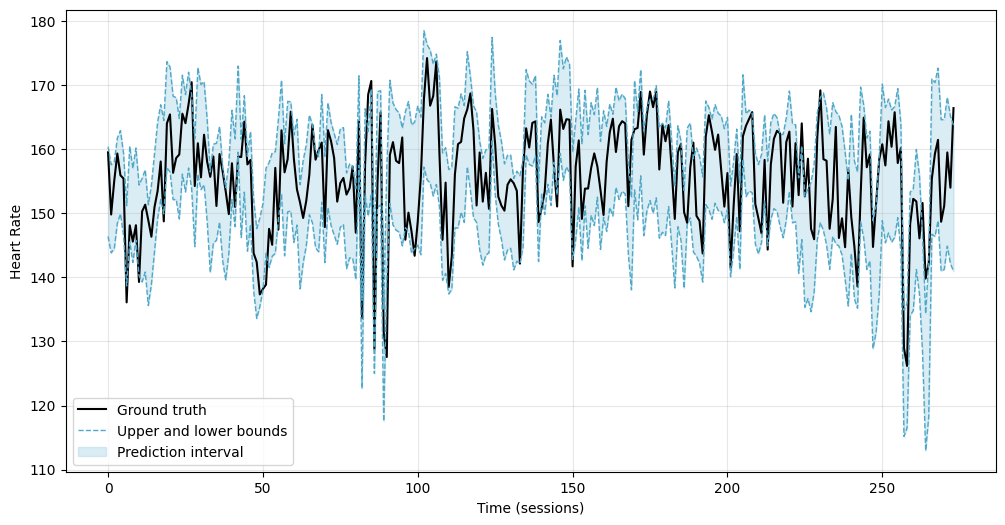

Figure saved


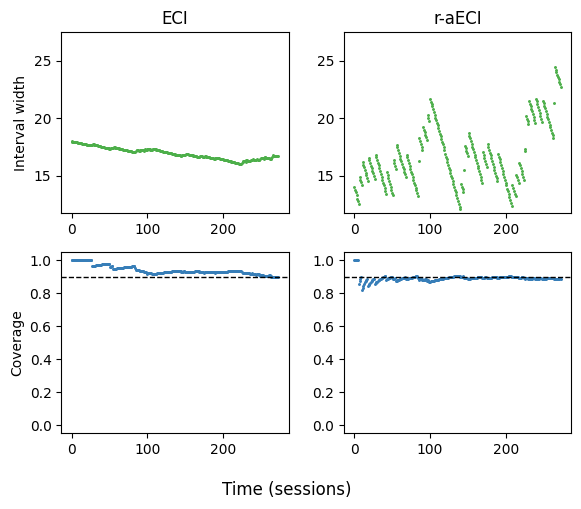

In [2]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([2])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.05,"q":9,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":1,"q":7,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

rows=[]
method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-45'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-22

0.8892307692307693 22.522896585577623 23.09587518890197
0.8892307692307693 22.163655111169216 23.231487728099296
Figure saved


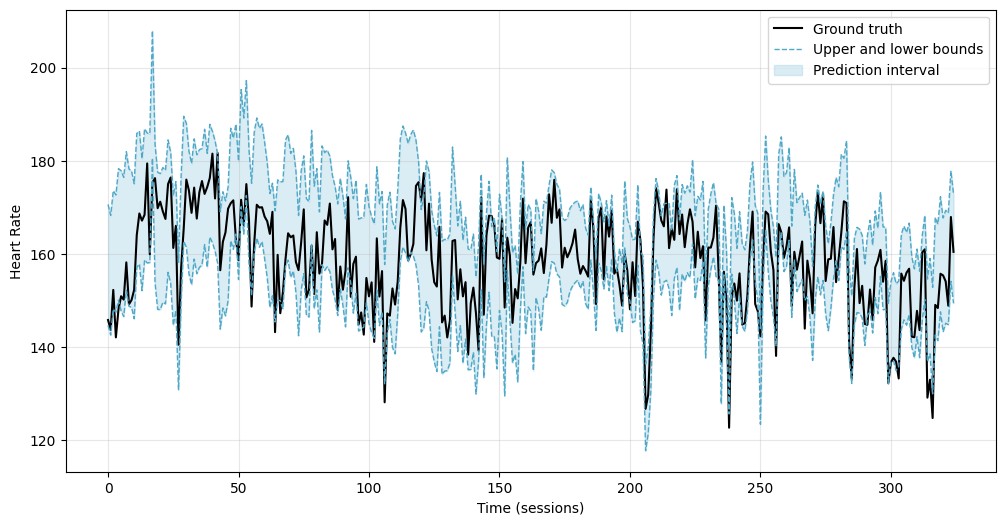

Figure saved


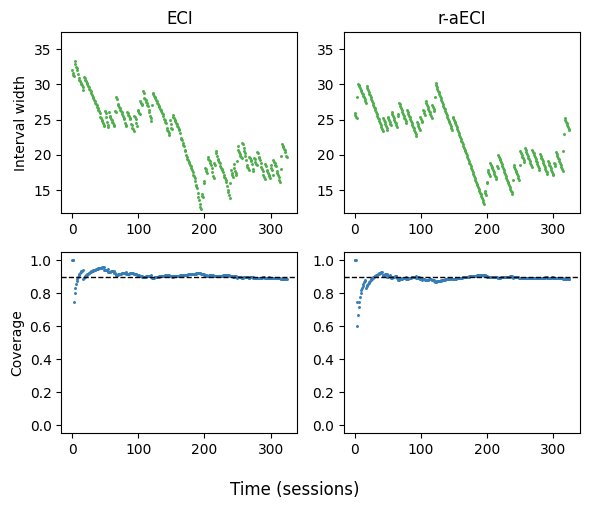

In [3]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([1])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":16,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":1,"q":13,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-22'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-08

0.896551724137931 21.690829934136875 21.734625406103532
0.8850574712643678 20.753432857295543 20.820861543027817


c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:295: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Figure saved


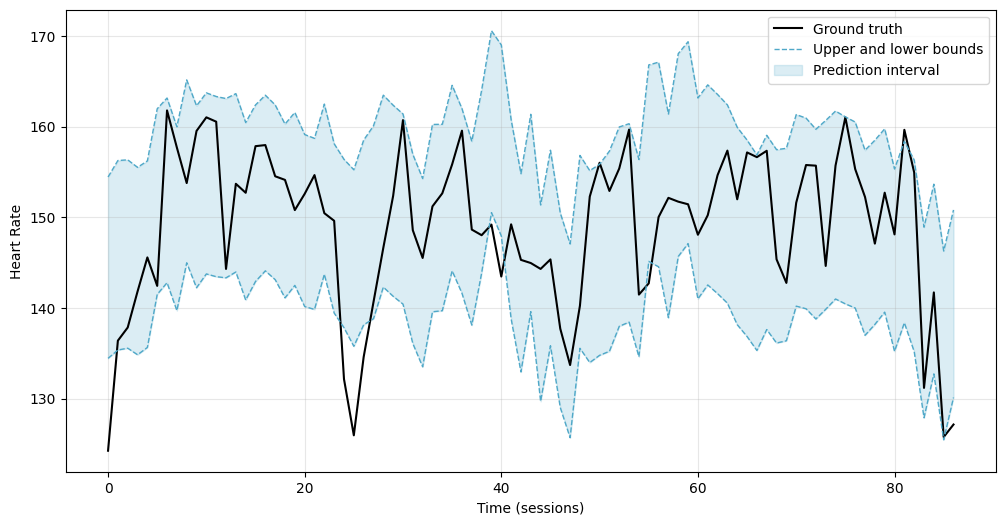

Figure saved


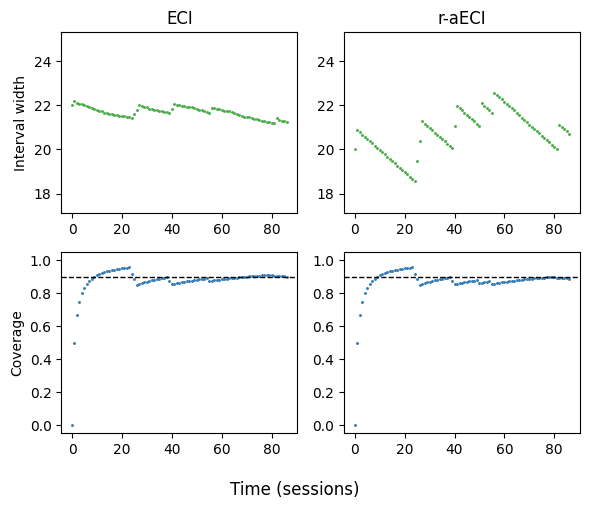

In [4]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([20])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.1,"q":11,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.5,"q":10,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-08'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-10

0.888 17.52007003092967 17.044689579732506
0.888 17.704611106181545 17.61091672580278
Figure saved


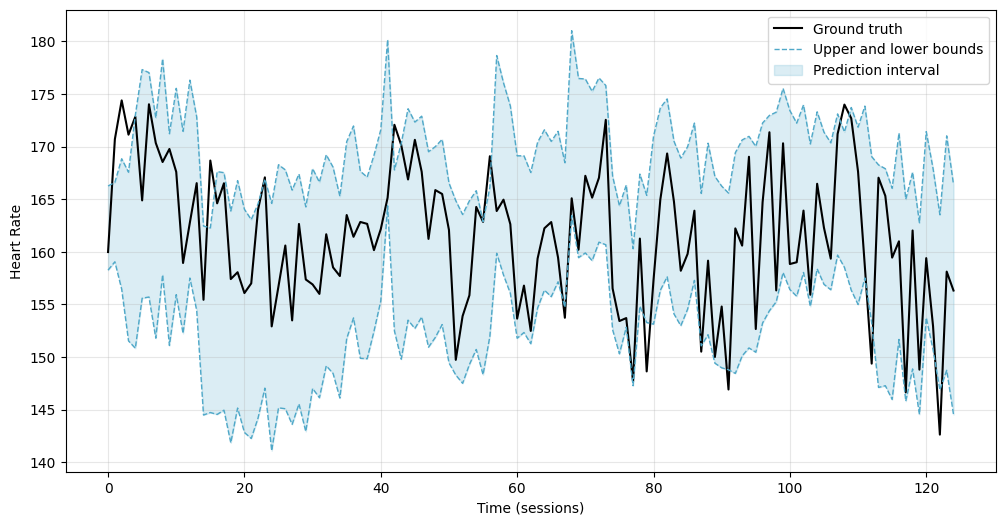

Figure saved


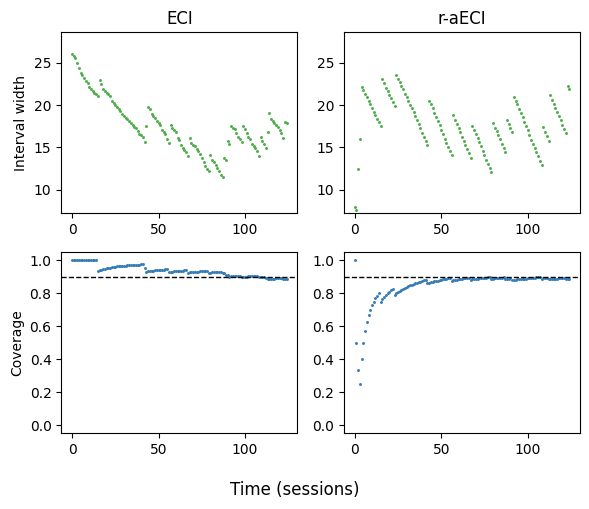

In [5]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([2])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":13,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":2,"q":4,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-10'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-07

0.8975741239892183 18.904051900995597 18.842579613800467
0.8867924528301887 17.71113133131284 17.52051817137999
Figure saved


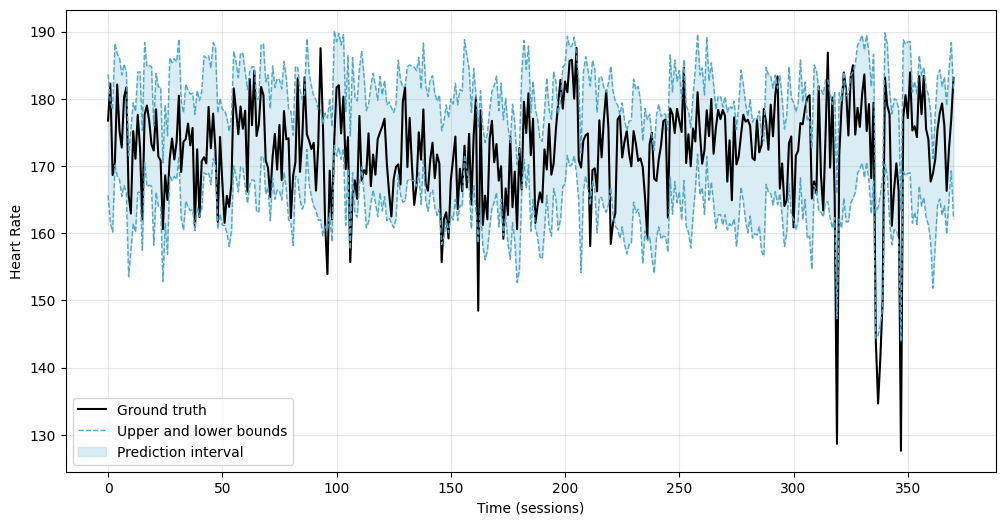

Figure saved


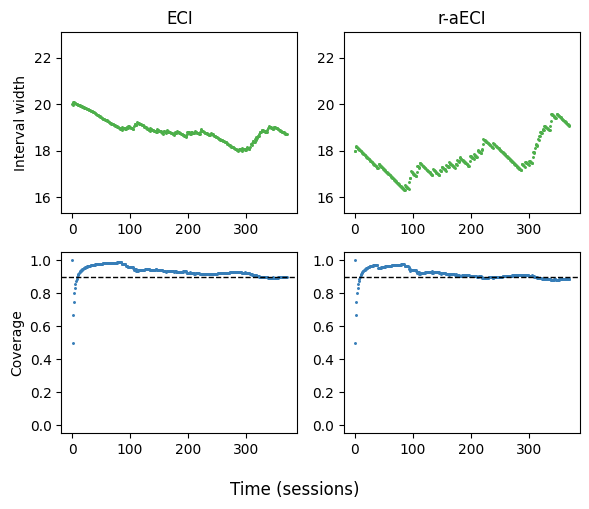

In [6]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([2])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.05,"q":10,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.1,"q":9,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-07'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-32

0.8943089430894309 15.74019939302334 15.72566146736267
0.9024390243902439 16.03088578221714 16.040012727132705
Figure saved


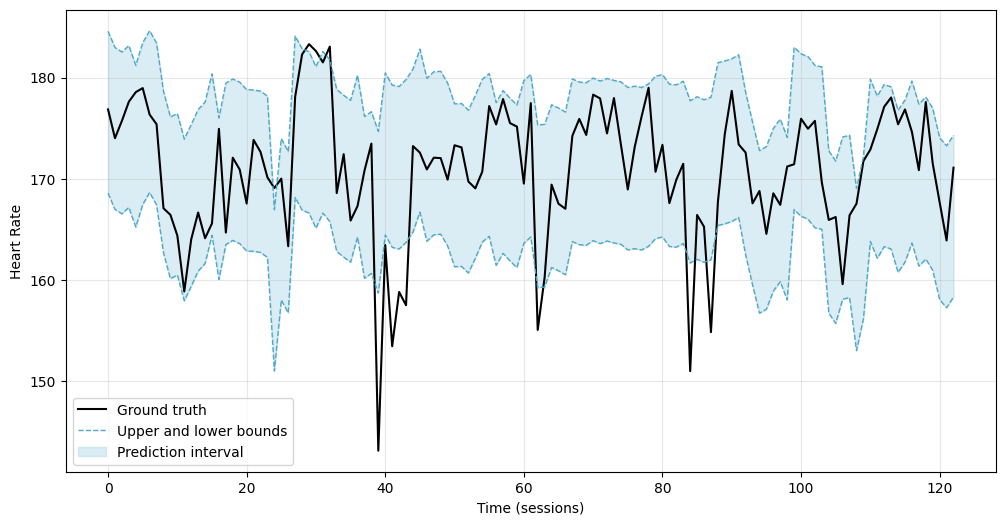

Figure saved


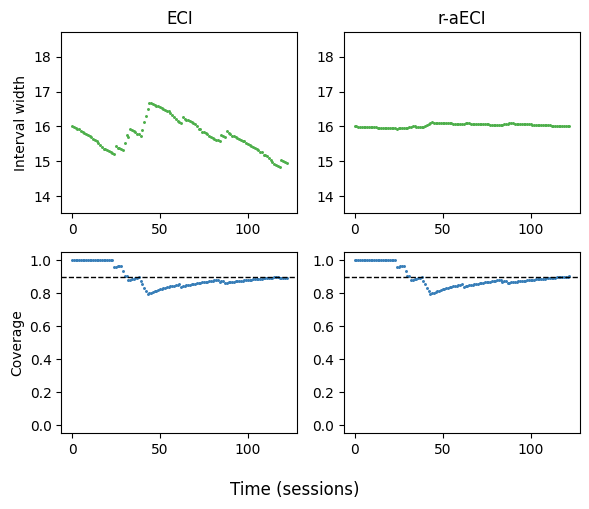

In [7]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([1])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.1,"q":8,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.01,"q":8,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-32'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-18

0.8851351351351351 19.45061692047245 19.453866636768595
0.8885135135135135 19.94399041308995 19.942839755673475
Figure saved


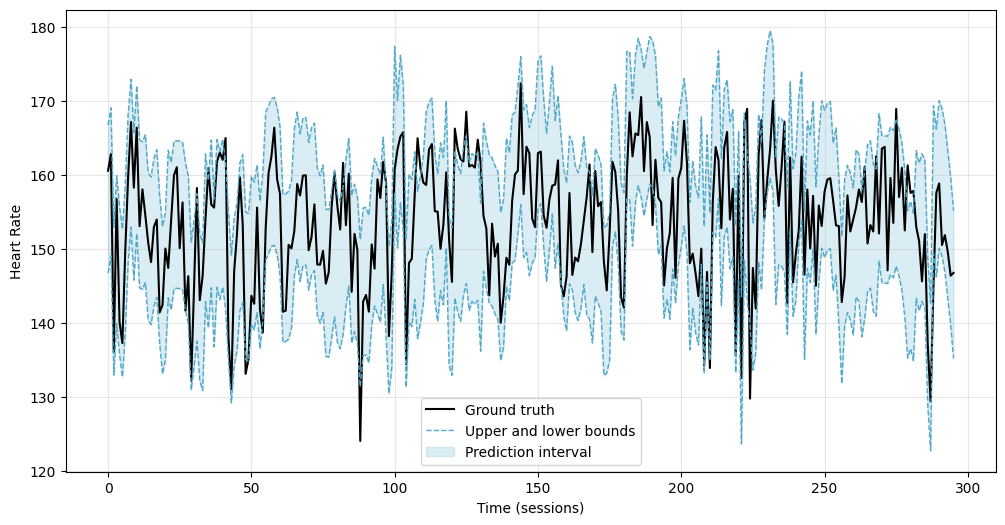

Figure saved


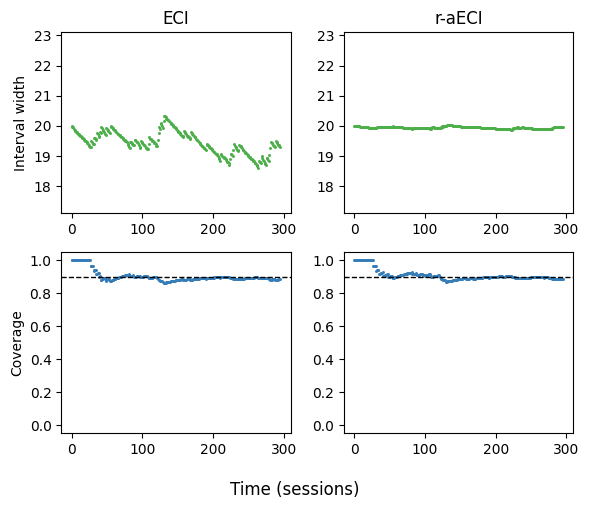

In [8]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([1])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.1,"q":10,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.01,"q":10,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-18'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-51

0.8857142857142857 19.924746458335818 19.921982787127604
0.8857142857142857 19.85958683618937 19.89589003926909
Figure saved


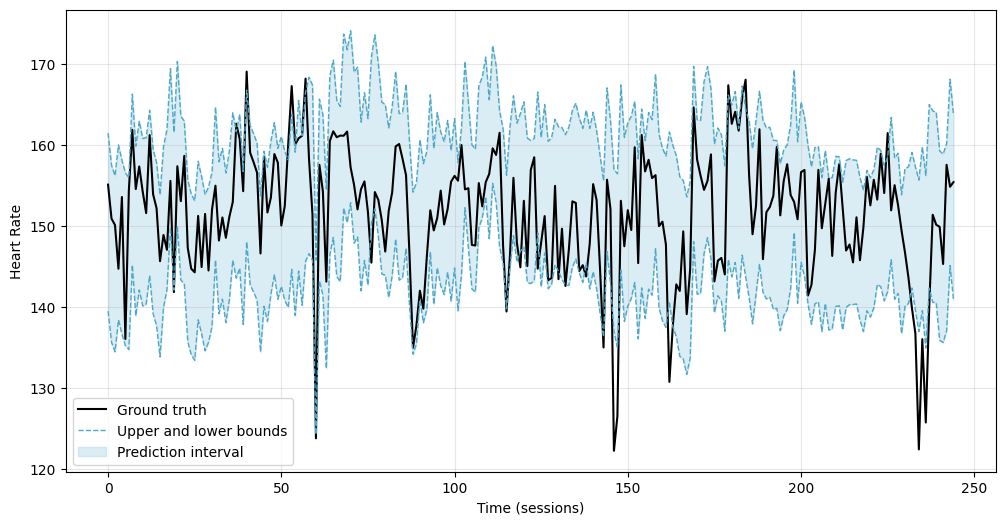

Figure saved


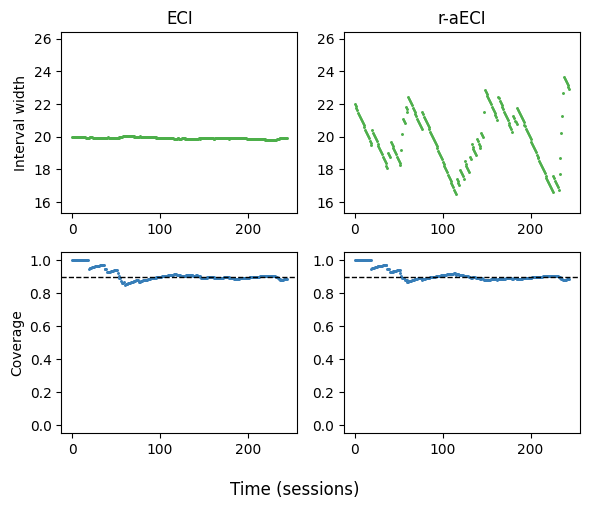

In [9]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([1])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.01,"q":10,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.5,"q":11,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-51'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-71

0.898989898989899 16.59387857890709 16.02363112868443
0.8888888888888888 15.640302791925338 15.10664730584449
Figure saved


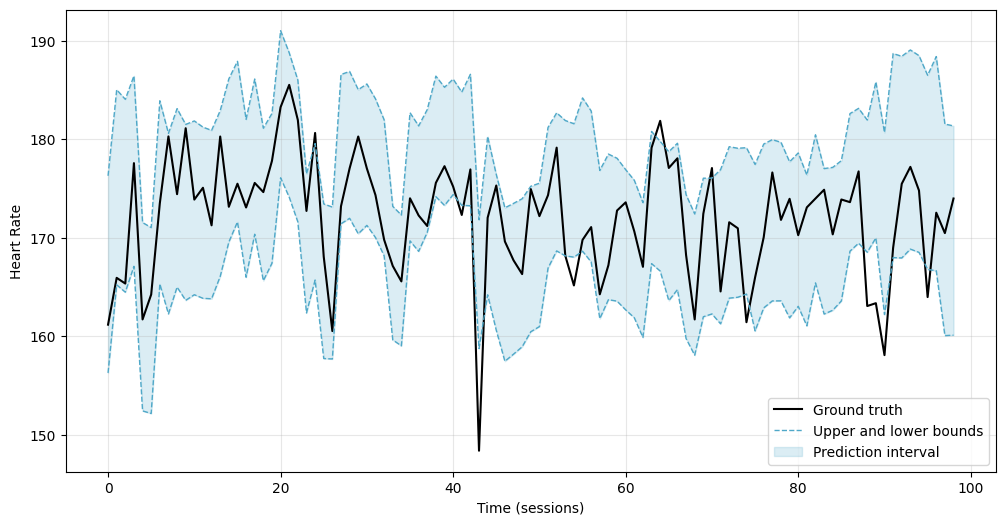

Figure saved


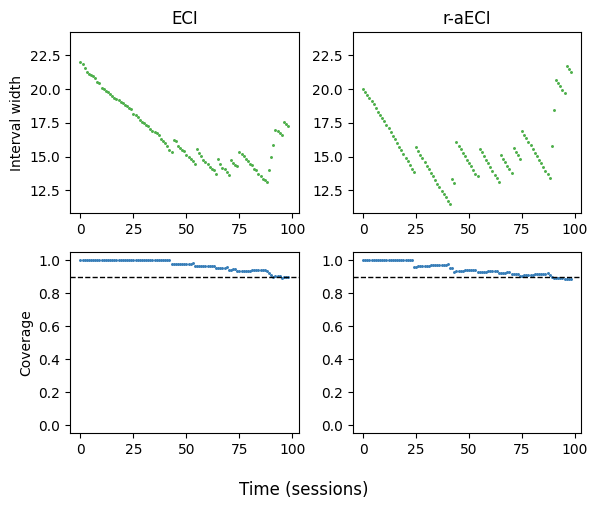

In [10]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([1])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.5,"q":11,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":1,"q":10,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-71'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-75

0.8942307692307693 20.492716905220636 20.99298574912342
0.8942307692307693 20.040706231705915 20.47505136533198
Figure saved


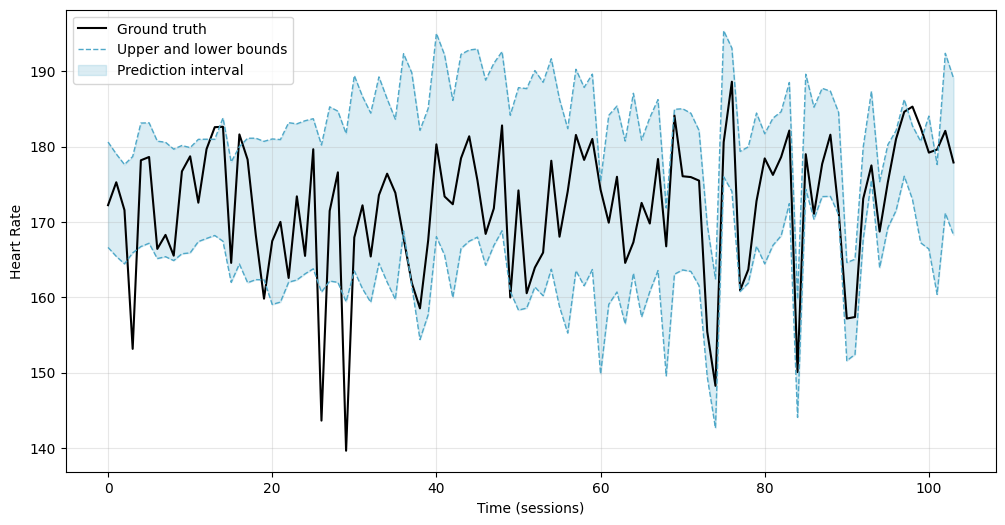

Figure saved


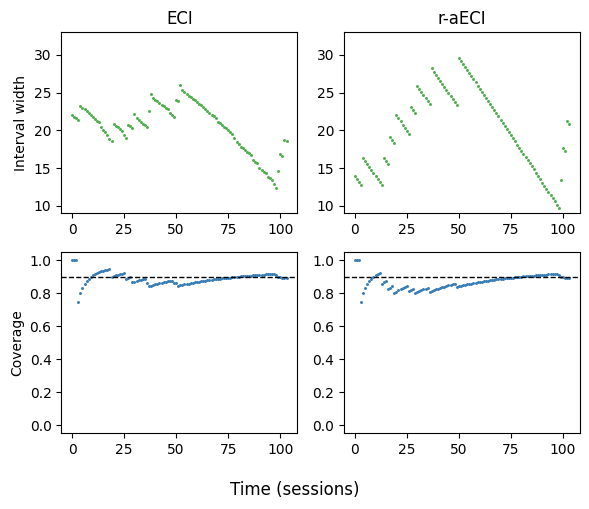

In [11]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([15])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":11,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":2,"q":7,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-75'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-19

0.8853503184713376 20.605726514517574 21.053486956100528
0.89171974522293 18.855355453127743 18.87970885924517
Figure saved


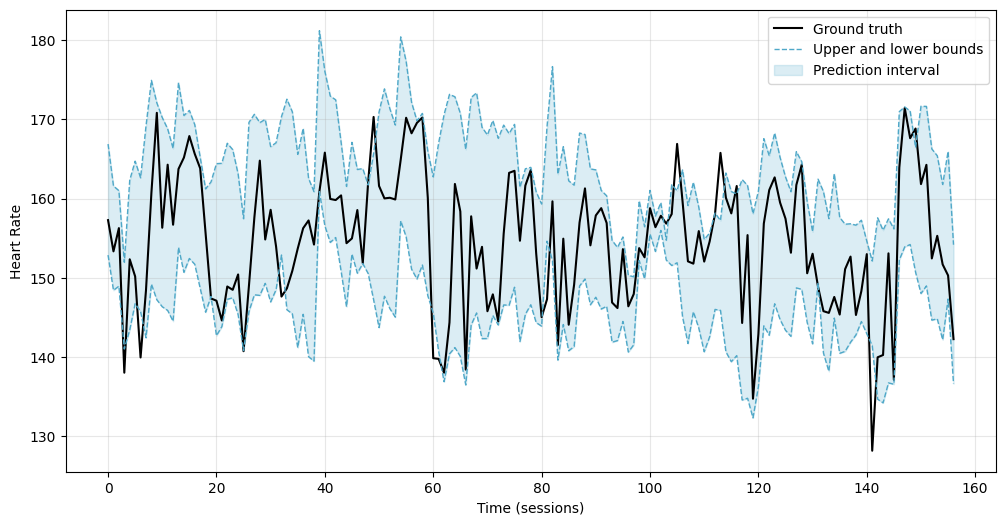

Figure saved


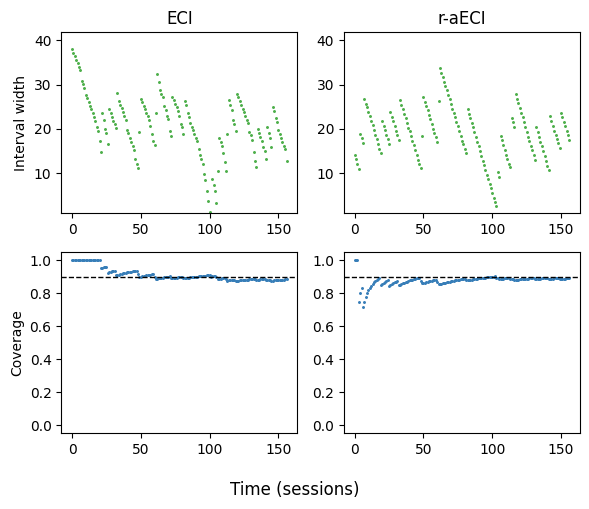

In [12]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([1])

method="ECI"
method_params = {"ECI_sig":{"l_r":4,"q":19,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":4,"q":7,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-19'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-65

0.8877005347593583 21.829335180211462 21.814511290262942
0.8877005347593583 21.242892451170285 21.200234044817876
Figure saved


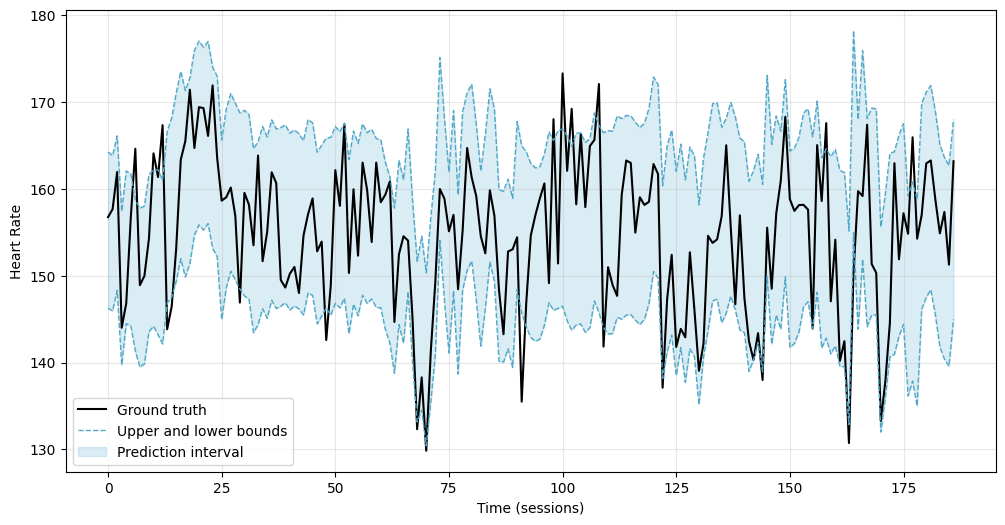

Figure saved


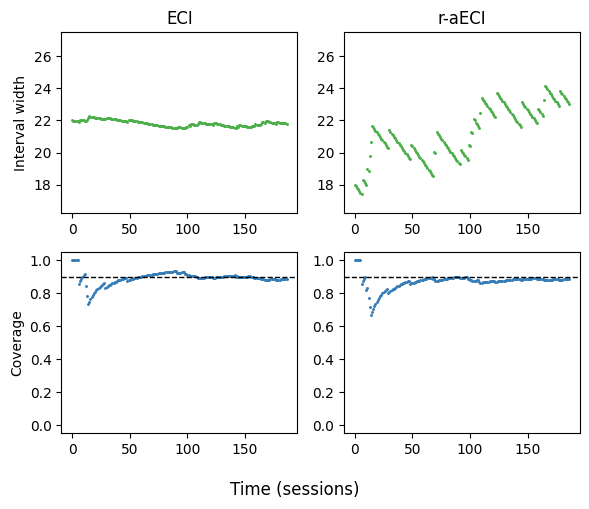

In [13]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([16])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.05,"q":11,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.5,"q":9,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-65'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-59

0.8903225806451613 22.300185937138878 21.366113723663602
0.8903225806451613 21.269407135818735 21.27463307168722
Figure saved


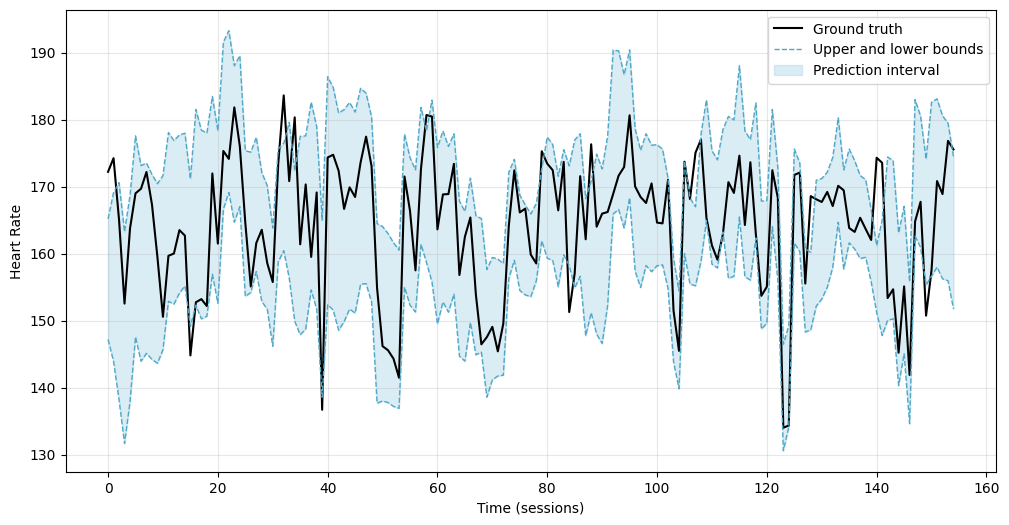

Figure saved


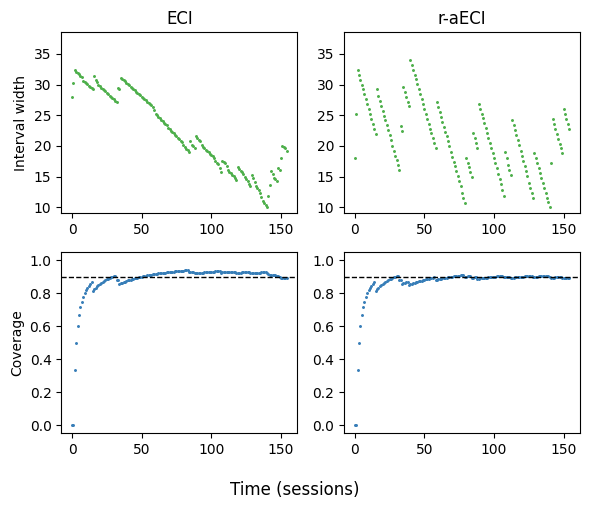

In [14]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([19])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":14,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":4,"q":9,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-59'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-55

0.8900709219858156 23.565064766748836 23.532465614202636
0.8865248226950354 22.84232630616629 23.196423999510614
Figure saved


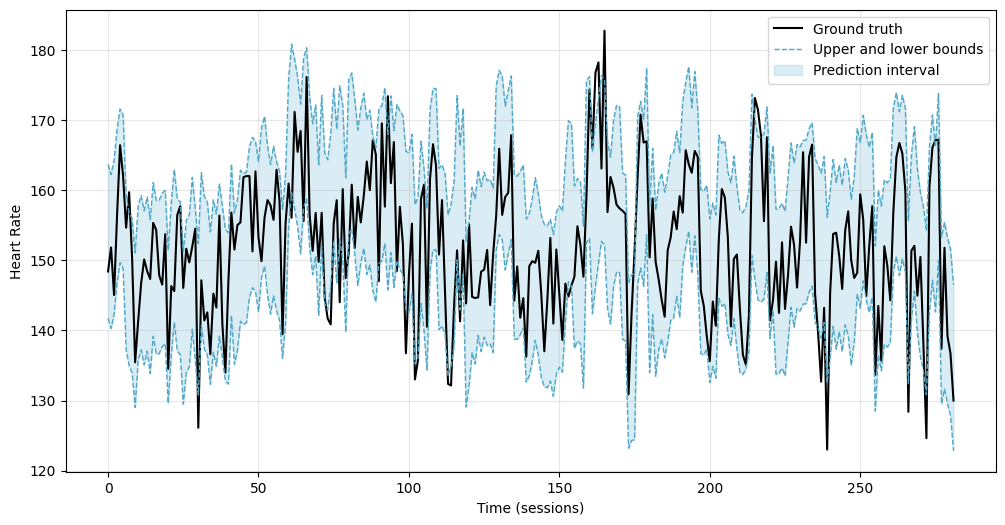

Figure saved


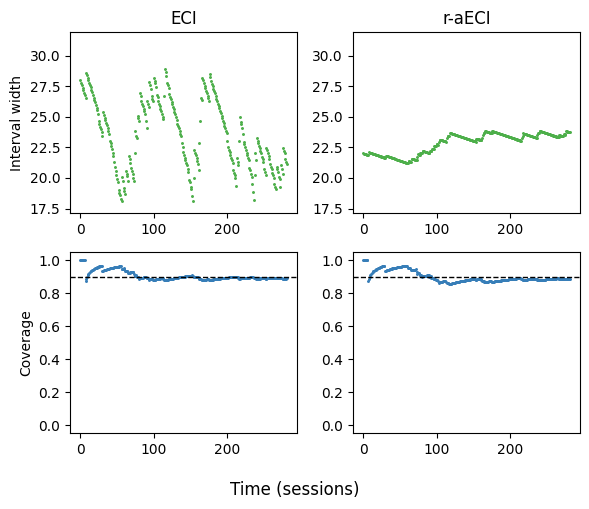

In [15]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([12])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":14,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.1,"q":11,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-55'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-53

0.8888888888888888 22.58112626347343 22.600555643318728
0.8888888888888888 21.823132937581885 21.403070101578294
Figure saved


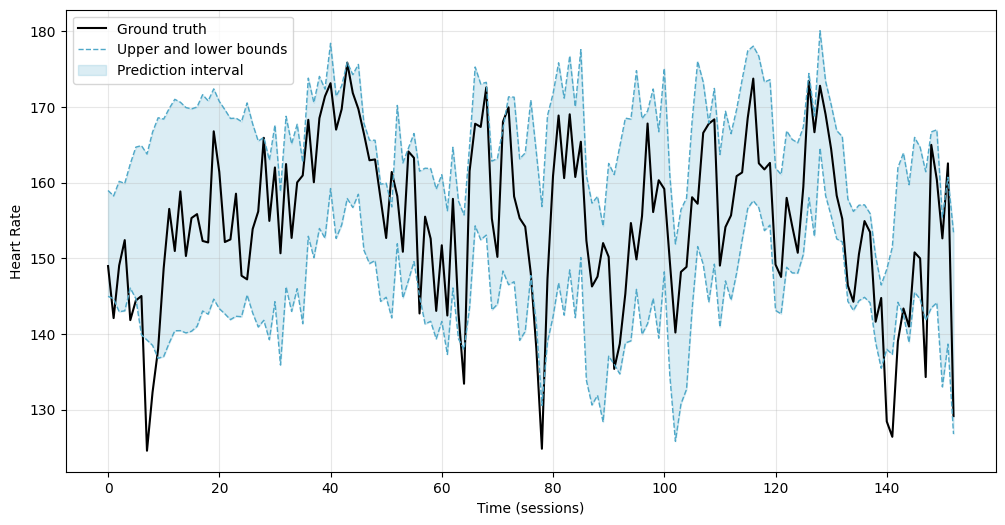

Figure saved


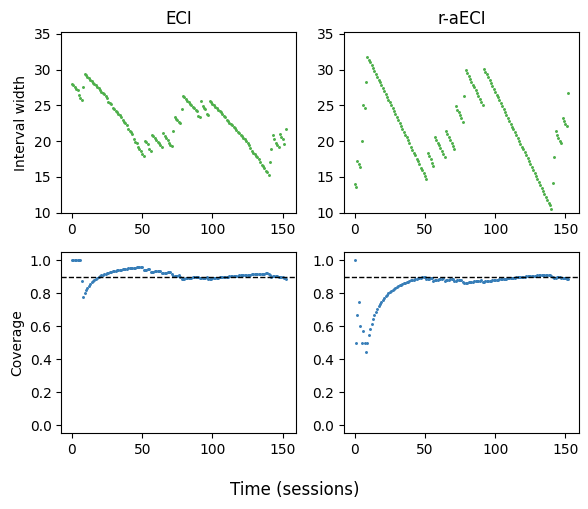

In [16]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([14])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":14,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":2,"q":7,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-53'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-39

0.8855721393034826 22.642892892137308 21.87542155057548
0.8855721393034826 22.520815565172597 24.11052504058722
Figure saved


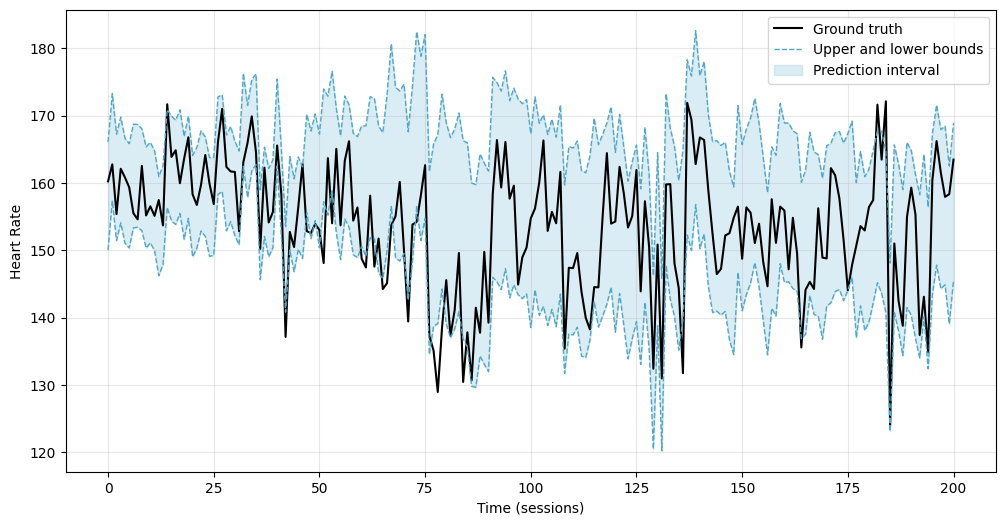

Figure saved


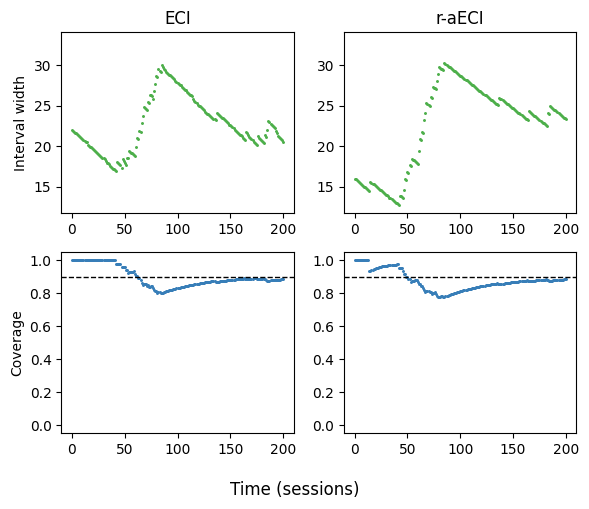

In [17]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([6])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.5,"q":11,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.5,"q":8,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-39'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-25

0.8857142857142857 23.339829419506398 23.337716337121755
0.8885714285714286 22.761353741901225 22.794336152876873
Figure saved


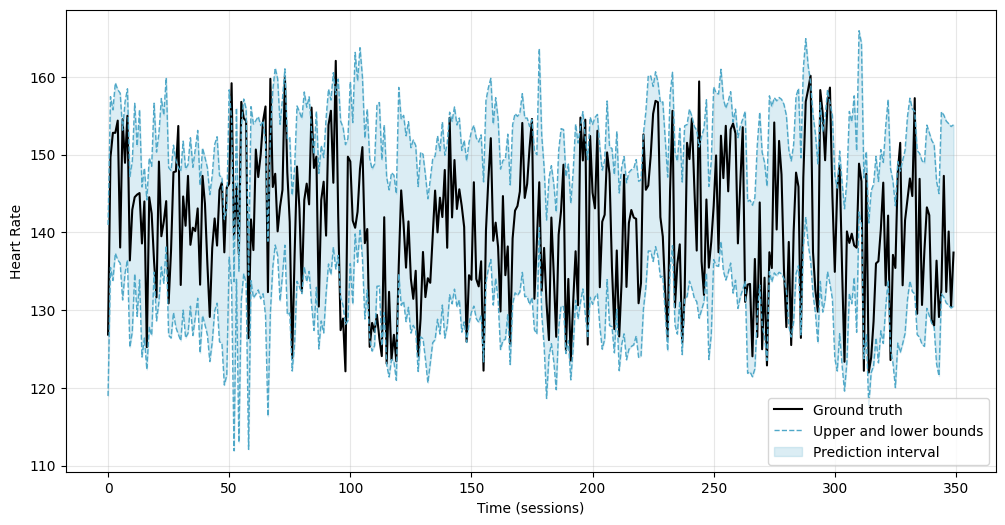

Figure saved


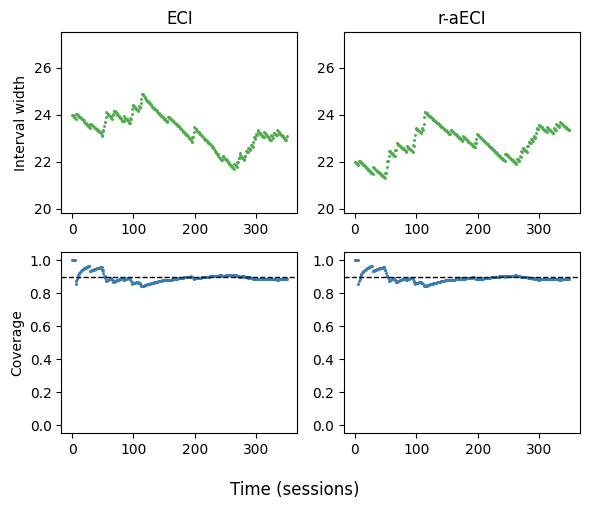

In [18]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([2])

method="ECI"
method_params = {"ECI_sig":{"l_r":0.1,"q":12,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":0.1,"q":11,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-25'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)

##### MHSC-16

0.8865979381443299 24.65194611273599 25.131949427642894
0.8891752577319587 23.998105907350833 24.75459637347052
Figure saved


c:\Users\tdupuy\Documents\Thèse\Online_CP\OCP_relevance_special_issue\utils.py:295: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


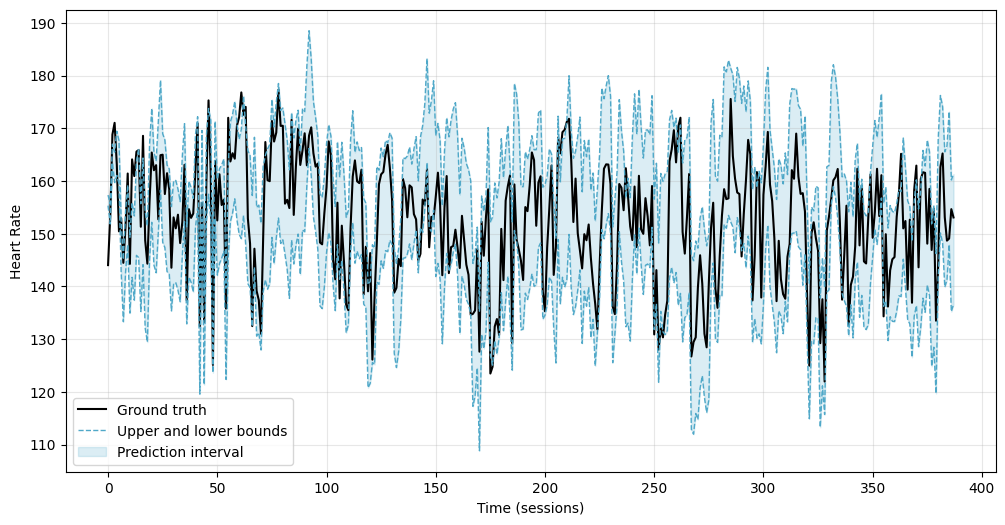

Figure saved


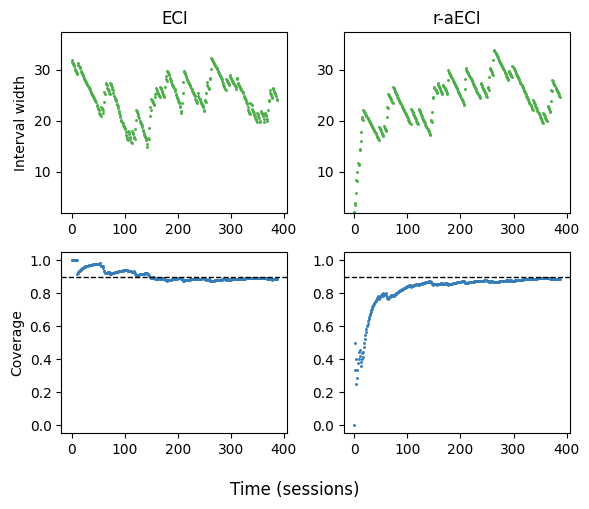

In [19]:
df=pd.read_excel('./datasets/global_data_7_july_2023_16_may_2025.xlsx')
dataset="HR"
basemodel="KR"
size_train=0.70
cv_search=3
cv_method="TSSplit"
n_iter_search=100
with_acute_load=True
retrain_every_n_steps=30
sliding=True

alpha=0.1    
w=np.array([1])
v=np.array([3])

method="ECI"
method_params = {"ECI_sig":{"l_r":1,"q":16,"f_dev":dev_sigmoid_c(1)},"ECI_my":{"l_r":1,"q":1,"f_dev":dev_f_w_v(w,v,alpha)}}
name_methods=list(method_params.keys())

method_to_title={"ECI_sig":"ECI","ECI_my":"r-aECI"}

player='MHSC-16'
df_player=load_player(df,player)
results=dict.fromkeys(name_methods)
nb_obervations=df_player.shape[0]
start_train=1
end_train=int(nb_obervations*size_train)
start_test=end_train+1
end_test=nb_obervations
for name_method,params in method_params.items(): 
    result=exe_player(df_player, player,start_train, end_train, start_test, end_test, basemodel,method, alpha,cv_search, cv_method, n_iter_search,with_acute_load,retrain_every_n_steps,sliding=sliding,q1=params['q'],lr=params['l_r'],f_dev=params['f_dev'])
    results[name_method]=result
    cov,mean_width,median_width=means_exp(result)
    player_number='Player '+player.split('-')[1]
    rows.append({"player":player_number,"method":method_to_title[name_method],"width_mean":mean_width})
    print(cov,mean_width,median_width)
title=f'exp2_{dataset}_{player}_{basemodel}'
title_interval=f'exp2_{dataset}_{player}_{basemodel}_interval_evolution'
plot_evolution(results["ECI_my"],title_interval)
plot_exp(title,results,name_methods,method_to_title)